In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal

In [ ]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42369 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:42369/status,
Dashboard: http://127.0.0.1:42369/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46231,Workers: 0
Dashboard: http://127.0.0.1:42369/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37681,Total threads: 4
Dashboard: http://127.0.0.1:44795/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:36045,


2025-11-06 11:55:51,925 - distributed.nanny - WARNING - Restarting worker


In [3]:
#client.close()

In [4]:
path_atm = "/projects/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7fcfb0936e80>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID
Exception ignored in: <function CachingFileManager.__del__ at 0x7fa7ea6bee80>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/ni

### Sulfate burden and SO2 concentrations

In [64]:
ds["SFSO2"]

<xarray.DataArray 'SFSO2' (time: 476, lat: 192, lon: 288)> Size: 105MB
dask.array<concatenate, shape=(476, 192, 288), dtype=float32, chunksize=(1, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time     (time) object 4kB 1975-02-01 00:00:00 ... 2014-12-01 00:00:00
Attributes:
    units:         kg/m2/s
    long_name:     SO2 surface flux
    cell_methods:  time: mean

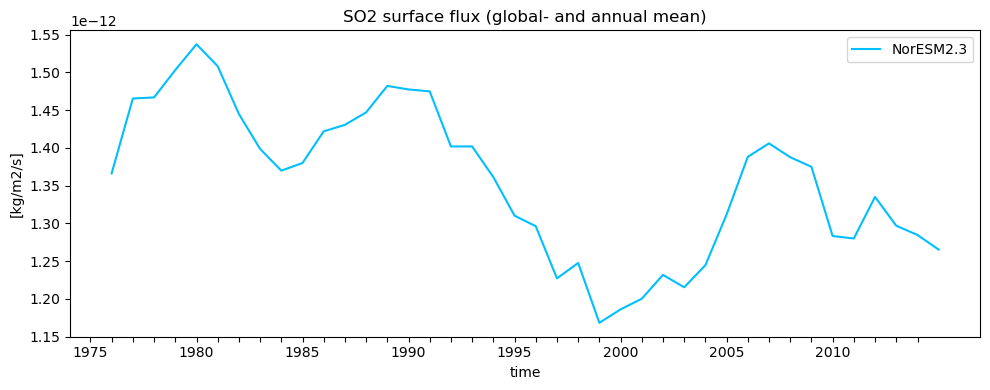

In [ ]:
lat = ds["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
so2_surf = ds["SFSO2"].weighted(weighted_lat).mean(dim=["lat", "lon"])
so2_surf = so2_surf.resample(time="1YE").mean()



plt.figure(figsize=(10, 4))
so2_surf.plot(color="deepskyblue", label="NorESM2.3")
plt.ylabel("[kg/m2/s]")
years = np.arange(1975, 2015)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(year_ticks, [str(y) if y % 5 == 0 else '' for y in years])
plt.title("SO2 surface flux (global- and annual mean)")
plt.legend()
plt.tight_layout()
plt.show()

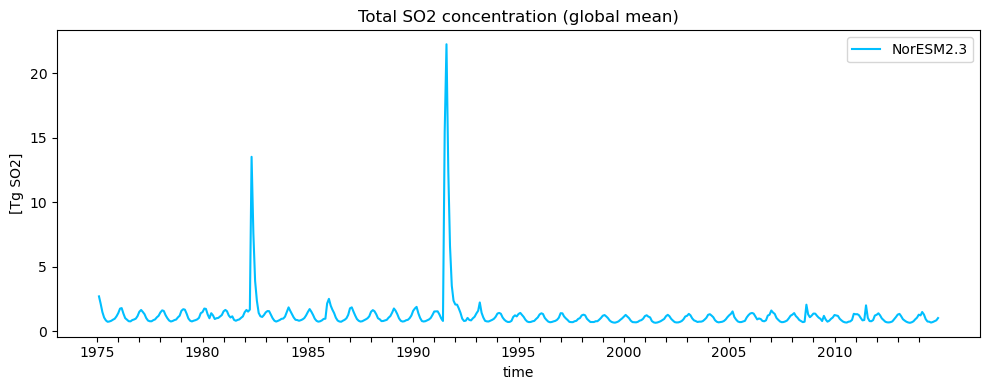

In [67]:
M_SO2 = 64.066     
M_air = 28.9647   
m_air_global = 5.3 * 10**21 
K_so2 = (M_SO2 / M_air) * m_air_global *10**(-12)    # mol/mol → Tg conversion factor

lat = ds["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
so2 = ds["SO2"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])

so2_tg = so2 * K_so2

plt.figure(figsize=(10, 4))
so2_tg.plot(color="deepskyblue", label="NorESM2.3")
plt.ylabel("[Tg SO2]")
years = np.arange(1975, 2015)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(year_ticks, [str(y) if y % 5 == 0 else '' for y in years])
plt.title("Total SO2 concentration (global mean)")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
Ms = 32.065 
Mair = 28.96  # dry air
Matmos = 5.3 * 10**21
K = (Ms/Mair) * Matmos *10**(-12)

Text(0.5, 1.0, 'Total S concentration (global mean)')

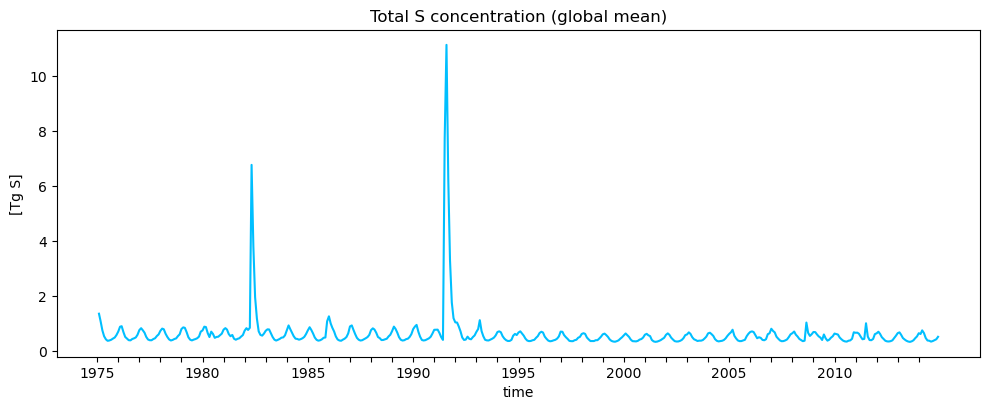

In [7]:
lat = ds["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
so2 = ds["SO2"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
so2_tg = so2 * K

plt.figure(figsize=(10, 4))
so2_tg.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[Tg S]")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.tight_layout()
plt.title("Total S concentration (global mean)")

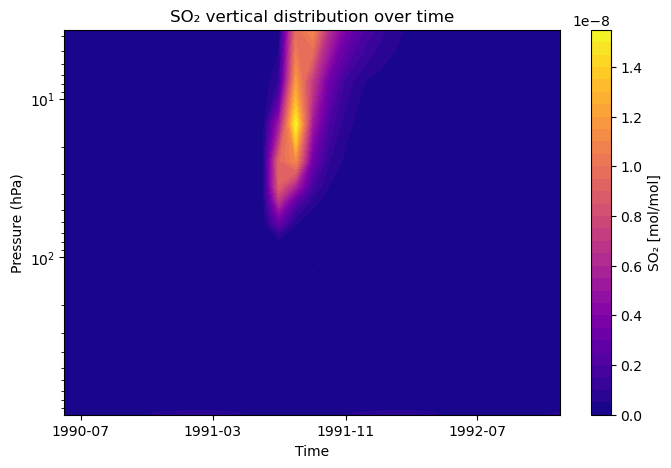

In [8]:
so2_profile = ds["SO2"].weighted(weighted_lat)
so2_time_lev = so2_profile.mean(dim=['lat','lon'])

so2_zoom = so2_time_lev.sel(time=slice('1990-06-01', '1992-12-01'))
time_zoom = so2_zoom['time'].values

time = ds['time'].values 
lev = ds['lev'].values

plt.figure(figsize=(8,5))
plt.contourf(time_zoom, lev, so2_zoom.T, levels=30, cmap='plasma')
plt.gca().invert_yaxis()
plt.yscale("log")
plt.colorbar(label='SO₂ [mol/mol]')
plt.xlabel('Time')
plt.ylabel('Pressure (hPa)')
plt.title('SO₂ vertical distribution over time')
plt.show()

### H2SO4 and sulfate

Text(0.5, 1.0, 'Total H2SO4 concentration (global mean)')

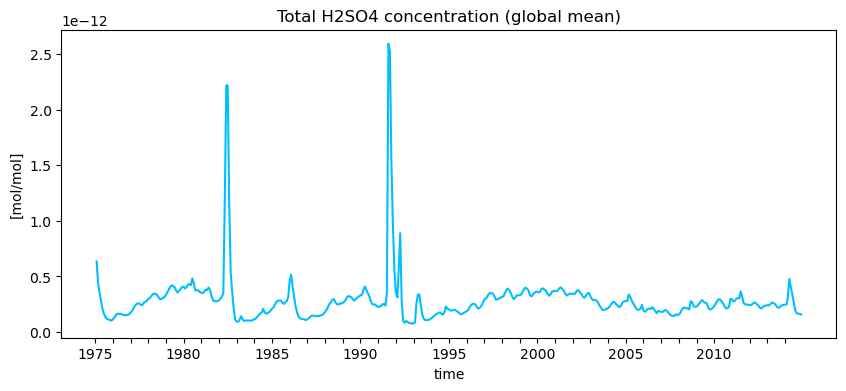

In [38]:
lat = ds["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
so4 = ds["H2SO4"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])


plt.figure(figsize=(10, 4))
so4.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[mol/mol]")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Total H2SO4 concentration (global mean)")

Text(0.5, 1.0, 'Mass mixing ratio of Sulfate (global mean)')

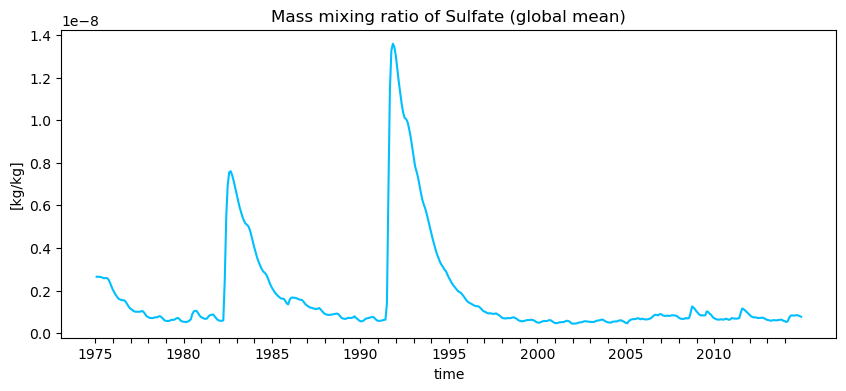

In [39]:
lat = ds["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
mmr_so4 = ds["mmr_SULFATE"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])


plt.figure(figsize=(10, 4))
mmr_so4.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[kg/kg]")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Mass mixing ratio of Sulfate (global mean)")

In [48]:
tropopause = ds["TROP_P"].weighted(weighted_lat).mean(dim=["lat", "lon"])

Exception ignored in: <function CachingFileManager.__del__ at 0x7fa7ea6bee80>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


Text(0.5, 1.0, 'Stratospheric burden of Sulfate (global mean)')

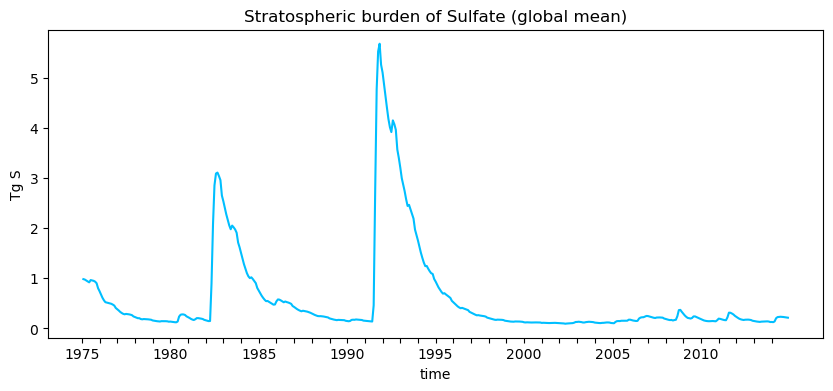

In [50]:
p_lev = tropopause * 0.01
M_strat_air = 0.099 * Matmos   #9.9% of the total mass of the atmosphere
Mo = 15.999
Mso4 = Ms + (4 * Mo)
c = Ms/Mso4

mmr_sulf = ds["mmr_SULFATE"]
so4_burd = mmr_sulf.where(mmr_sulf["lev"] <= p_lev)
so4_burd = so4_burd.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
so4_burden = so4_burd * M_strat_air *10**(-12)
so4_burden_TgS = so4_burden * c

plt.figure(figsize=(10, 4))
so4_burden_TgS.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("Tg S")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Stratospheric burden of Sulfate (global mean)")

Text(0.5, 1.0, 'Stratospheric burden of Sulfate from Pinatubo (global mean) (-background)')

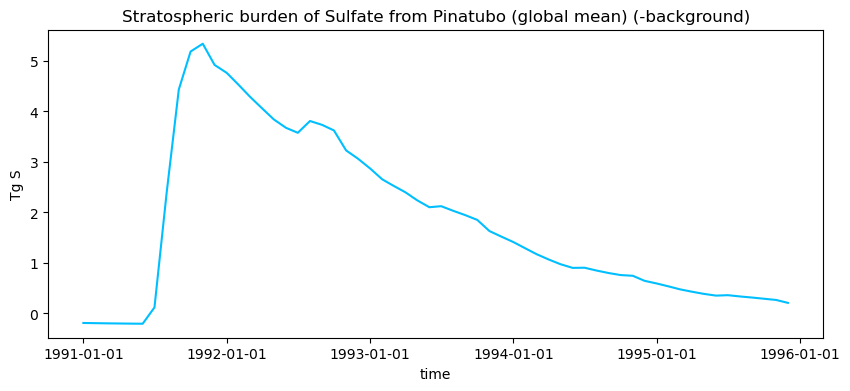

In [51]:
background = so4_burden_TgS.sel(time=[t for t in so4_burden_TgS.time.values if 1985 <= t.year <= 1990]).mean(dim="time")
so4_burd_Pinatubo = so4_burden_TgS.sel(time=[t for t in so4_burden_TgS.time.values if 1991 <= t.year <= 1995])
so4_burden_Pinatubo = so4_burd_Pinatubo - background

plt.figure(figsize=(10, 4))
so4_burden_Pinatubo.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1991, 1997) 
year_ticks = [cftime.DatetimeNoLeap(y, 1, 1) for y in years]
plt.xticks(
    year_ticks
)
plt.ylabel("Tg S")
plt.title("Stratospheric burden of Sulfate from Pinatubo (global mean) (-background)")

In [52]:
a_glob = 510000000
h_trop = 4440
d = 12756

a_trop = np.pi * d * h_trop
ratio = a_trop/a_glob

Text(0.5, 1.0, 'Stratospheric burden of Sulfate (Tropics)')

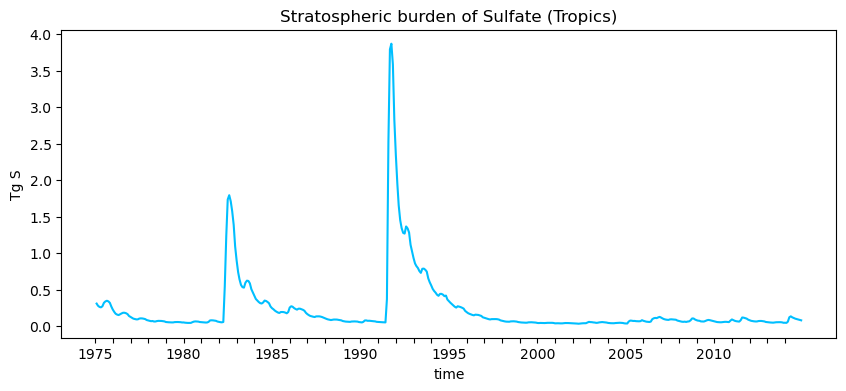

In [53]:
so4_trop = mmr_sulf.sel(lat=slice(-20, 20))
so4_burd_trop = so4_trop.where(so4_trop["lev"] <= p_lev)
so4_burd_trop = so4_burd_trop.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
so4_burden_trop = so4_burd_trop * M_strat_air * ratio *10**(-12)
so4_burden_TgS_trop = so4_burden_trop * c
so4_burden_TgS_trop_Pin = so4_burden_TgS_trop.sel(time=[t for t in so4_burden_TgS_trop.time.values if 1991 <= t.year <= 1995])

plt.figure(figsize=(10, 4))
so4_burden_TgS_trop.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("Tg S")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Stratospheric burden of Sulfate (Tropics)")

In [54]:
path_obs = "/nird/projects/NS1004K/elihho/obs_pinatubo/dataset/Observation"

In [55]:
hirs_sulf_burd = pd.read_csv(f"{path_obs}/hirs_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)
sage3l_sulf_burd = pd.read_csv(f"{path_obs}/sage3l_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)

start = pd.Timestamp("1991-01-01")
months = [int(c) for c in hirs_sulf_burd.columns]
dates = [start + pd.DateOffset(months=m) for m in months]
hirs_sulf_burd.columns = dates

months_sage = [int(c) for c in sage3l_sulf_burd.columns]
dates_sage = [start + pd.DateOffset(months=m) for m in months_sage]
sage3l_sulf_burd.columns = dates_sage

/tmp/ipykernel_719110/1286819563.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  hirs_sulf_burd = pd.read_csv(f"{path_obs}/hirs_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)
/tmp/ipykernel_719110/1286819563.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sage3l_sulf_burd = pd.read_csv(f"{path_obs}/sage3l_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)


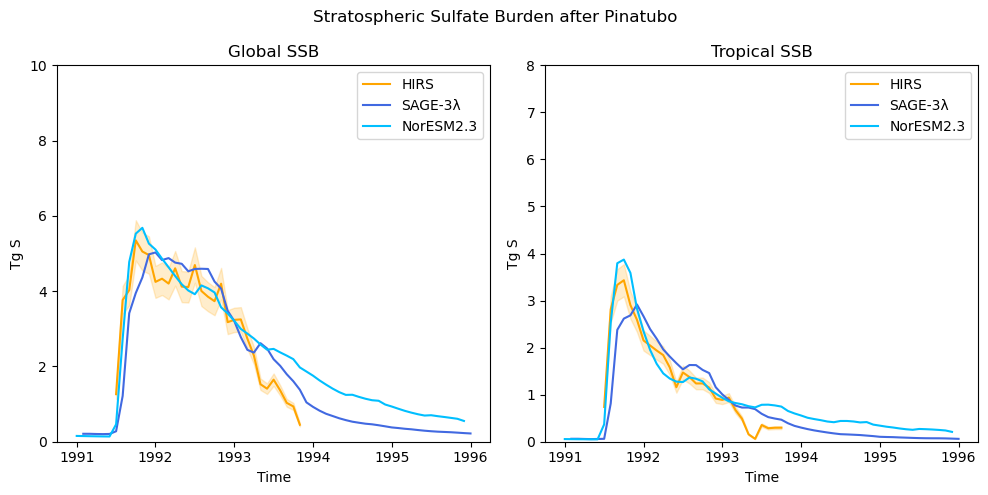

In [56]:
total = hirs_sulf_burd.loc["Total_burden"].astype(float)
trop  = hirs_sulf_burd.loc["Tropical_burden"].astype(float)
err_total = hirs_sulf_burd.loc["Total_burden_error"].astype(float)
err_trop =  hirs_sulf_burd.loc["Tropical_burden_error"].astype(float)
total_sage = sage3l_sulf_burd.loc["Global"].astype(float)
trop_sage  = sage3l_sulf_burd.loc["Tropical"].astype(float)

obs_time = np.array([t.year + (t.month-1)/12 for t in total_sage.index])
obs_time_hirs = np.array([t.year + (t.month-1)/12 for t in total.index])
time_years = np.array([t.year + (t.month-1)/12 for t in so4_burd_Pinatubo.time.values])

obs_time_trop = np.array([t.year + (t.month-1)/12 for t in trop_sage.index])
obs_time_hirs_trop = np.array([t.year + (t.month-1)/12 for t in trop.index])
time_years_trop = np.array([t.year + (t.month-1)/12 for t in so4_burden_TgS_trop_Pin.time.values])

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(obs_time_hirs, total, color="orange", label="HIRS")
ax[0].fill_between(obs_time_hirs, total - err_total, total + err_total,
                 color="orange", alpha=0.2)
ax[0].plot(obs_time, total_sage, color="royalblue", label="SAGE-3λ")
ax[0].plot(time_years, so4_burd_Pinatubo, color = "deepskyblue", label = "NorESM2.3")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Tg S")
ax[0].set_ylim(0,10)
ax[0].set_title("Global SSB")
ax[0].legend()

ax[1].plot(obs_time_hirs_trop,  trop,  color="orange", label="HIRS")
ax[1].fill_between(obs_time_hirs_trop, trop - err_trop, trop + err_trop,
                 color="orange", alpha=0.2)
ax[1].plot(obs_time_trop, trop_sage, color="royalblue", label="SAGE-3λ")
ax[1].plot(time_years_trop, so4_burden_TgS_trop_Pin, color = "deepskyblue", label = "NorESM2.3" )
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Tg S")
ax[1].set_ylim(0,8)
ax[1].set_title("Tropical SSB")
ax[1].legend()


fig.suptitle("Stratospheric Sulfate Burden after Pinatubo")
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Sulphur in form of SO2 and SO4 after Pinatubo')

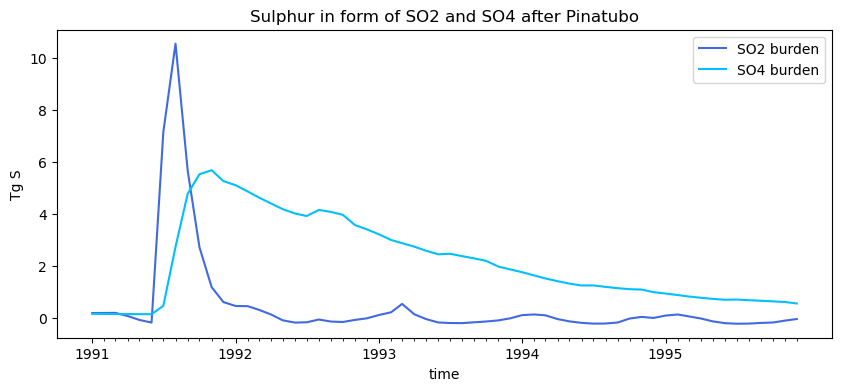

In [57]:
bg = so2_tg.sel(time=[t for t in so2_tg.time.values if 1985 <= t.year <= 1990]).mean(dim="time")
so2_Pinatubo = so2_tg.sel(time=[t for t in so2_tg.time.values if 1991 <= t.year <= 1995])
so2_burden_Pinatubo = so2_Pinatubo - bg

"""background = so4_burden_TgS.sel(time=[t for t in so4_burden_TgS.time.values if 1985 <= t.year <= 1990]).mean(dim="time")
so4_burd_Pinatubo = so4_burden_TgS.sel(time=[t for t in so4_burden_TgS.time.values if 1991 <= t.year <= 1995])
so4_burden_Pinatubo = so4_burd_Pinatubo - background"""

plt.figure(figsize=(10, 4))
so2_burden_Pinatubo.plot(color = "royalblue", label = "SO2 burden")
so4_burd_Pinatubo.plot(color = "deepskyblue", label = "SO4 burden")
years = np.arange(1991, 1996) 
year_ticks = [cftime.DatetimeNoLeap(y, 1, 1) for y in years]
month_ticks = [cftime.DatetimeNoLeap(y, m, 1) for y in years for m in range(1, 13)]
plt.xticks(year_ticks, [str(y) for y in years])
ax = plt.gca()
ax.set_xticks(month_ticks, minor=True)
plt.ylabel("Tg S")
plt.legend()
plt.title("Sulphur in form of SO2 and SO4 after Pinatubo")

### AOD

In [19]:
glossac_saod = pd.read_csv(f"{path_obs}/glossac_saod.txt", delim_whitespace=True, header=0,  index_col=0)
avhrr_saod = pd.read_csv(f"{path_obs}/avhrr_saod.txt", delim_whitespace=True, header=0,  index_col=0)

/tmp/ipykernel_719110/2537514140.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  glossac_saod = pd.read_csv(f"{path_obs}/glossac_saod.txt", delim_whitespace=True, header=0,  index_col=0)
/tmp/ipykernel_719110/2537514140.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  avhrr_saod = pd.read_csv(f"{path_obs}/avhrr_saod.txt", delim_whitespace=True, header=0,  index_col=0)


In [20]:
start = pd.Timestamp("1991-01-01")
months_glossac = [int(c) for c in glossac_saod.columns]
dates_glossac = [start + pd.DateOffset(months=m) for m in months_glossac]
glossac_saod.columns = dates_glossac

months_avhrr = [int(c) for c in avhrr_saod.columns]
dates_avhrr = [start + pd.DateOffset(months=m) for m in months_avhrr]
avhrr_saod.columns = dates_avhrr

In [21]:
avhrr_global = avhrr_saod.loc["Global_mean"].astype(float)
glossac_global = glossac_saod.loc["Global_mean"].astype(float)

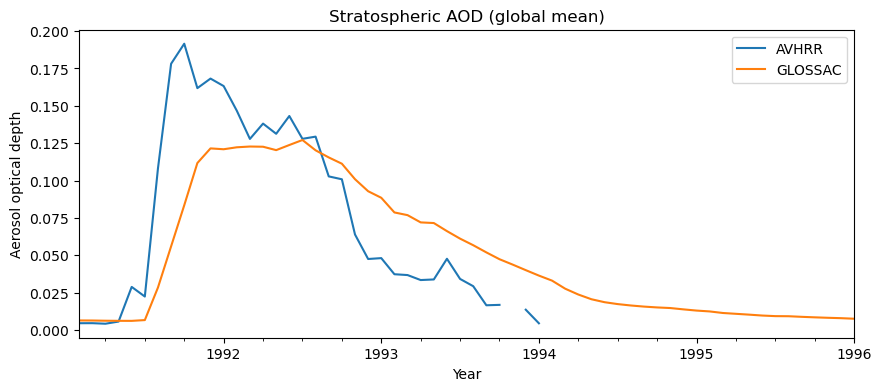

In [22]:
plt.figure(figsize=(10, 4))
avhrr_global.plot(label = "AVHRR")
glossac_global.plot(label="GLOSSAC")
plt.xlabel("Year")
plt.ylabel("Aerosol optical depth")
plt.title("Stratospheric AOD (global mean)")
plt.legend()
plt.show()

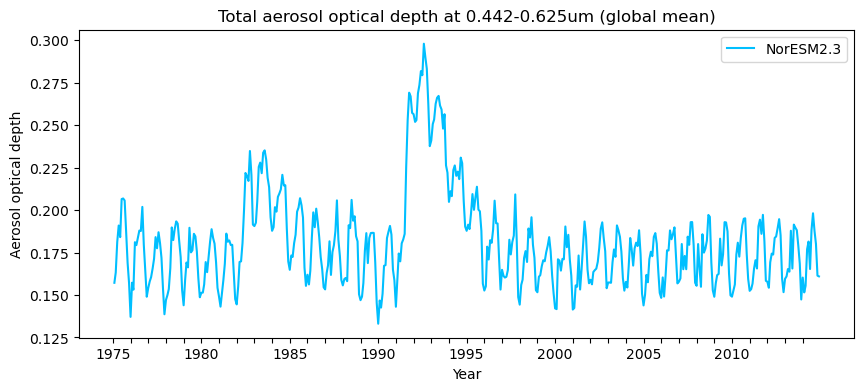

In [23]:
aod500 = "AOD_VIS"  # AOD at 0.442-0.625um
daylight = "DAYFOC"  # Fraction of day in the month

ts_aod = ds[aod500].weighted(weighted_lat).mean(dim=["lat", "lon"])
daylight_monthly = ds[daylight].weighted(weighted_lat).mean(dim=["lat", "lon"])
ts_aod = ts_aod / daylight_monthly
#ts_aod = ts_aod.resample(time="1YE").mean()

plt.figure(figsize=(10, 4))
ts_aod.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(year_ticks, [str(y) if y % 5 == 0 else '' for y in years])
plt.xlabel("Year")
plt.ylabel("Aerosol optical depth")
plt.title("Total aerosol optical depth at 0.442-0.625um (global mean)")
plt.legend()
plt.show()


Exception ignored in: <function CachingFileManager.__del__ at 0x7fcfb0936e80>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


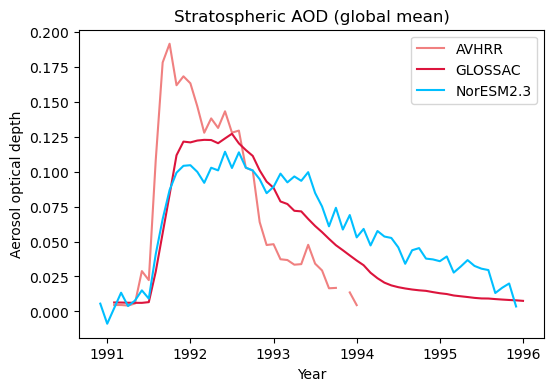

In [24]:
pre_eruption = ts_aod.sel(time=slice("2001-01", "2005-12"))
base = pre_eruption.groupby("time.month").mean("time")
aod_anom = ts_aod.groupby("time.month") - base
#pre_eruption = ts_aod.sel(time=slice("2001-01", "2005-12")).mean(dim="time")
#aod_anom = ts_aod - pre_eruption
aod_Pinatubo = aod_anom.sel(time=slice("1990-12", "1995-12"))
aod_smooth = aod_Pinatubo.rolling(time=1, center=True).mean()

obs_time_avhrr = np.array([t.year + (t.month-1)/12 for t in avhrr_global.index])
obs_time_glossac = np.array([t.year + (t.month-1)/12 for t in glossac_global.index])
time_years = np.array([t.year + (t.month-1)/12 for t in aod_Pinatubo.time.values])

plt.figure(figsize=(6, 4))
plt.plot(obs_time_avhrr, avhrr_global, color = "lightcoral", label = "AVHRR")
plt.plot(obs_time_glossac, glossac_global, color = "crimson", label = "GLOSSAC")
plt.plot(time_years, aod_Pinatubo, color = "deepskyblue", label = "NorESM2.3")
plt.xlabel("Year")
plt.ylabel("Aerosol optical depth")
plt.title("Stratospheric AOD (global mean)")
plt.legend()
plt.show()

/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


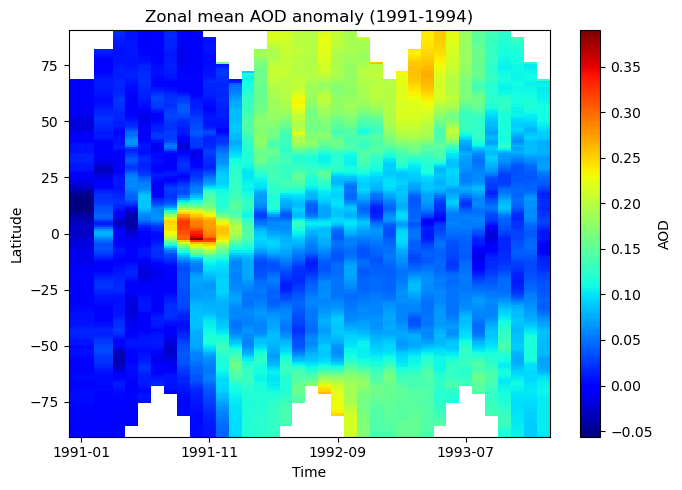

In [26]:
aod = ds[aod500]
daylight_monthly_nw = ds[daylight]
aod = aod / daylight_monthly_nw

baseline = aod.sel(time=slice("2001-01", "2005-12"))
base = baseline.groupby("time.month").mean("time")
aod_strat = aod.groupby("time.month") - base

aod_zoom = aod_strat.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom = aod_zoom['time'].values
aod_lat_time = aod_zoom.mean(dim="lon")
lat = aod_lat_time["lat"]

plt.figure(figsize=(7,5))
pc = plt.pcolormesh(
    time_zoom,
    lat,
    aod_lat_time.T, 
    shading="auto",  
    cmap="jet"
)

plt.colorbar(pc, label="AOD")
plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean AOD anomaly (1991-1994)")
plt.tight_layout()
plt.show()

## Ozone

Exception ignored in: <function CachingFileManager.__del__ at 0x7fa7ea6bee80>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


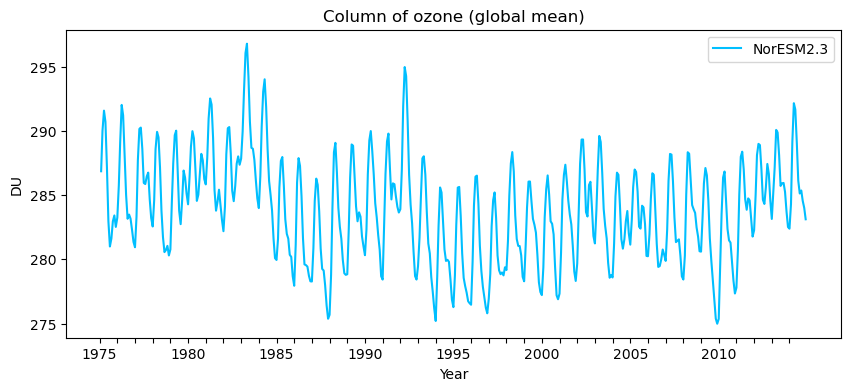

In [27]:
#  1DU = 2.1415e-05 kg/m2
DU = 1.0 / 2.1415e-05
cb_o3 = "cb_O3"

o3 = ds[cb_o3].weighted(weighted_lat).mean(dim=["lat", "lon"]) * DU

plt.figure(figsize=(10, 4))
o3.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(year_ticks, [str(y) if y % 5 == 0 else '' for y in years])
plt.xlabel("Year")
plt.ylabel("DU")
plt.title("Column of ozone (global mean)")
plt.legend()
plt.show()

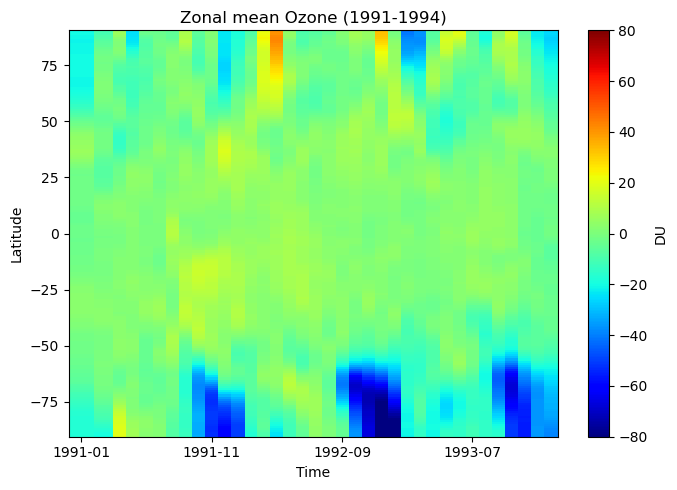

In [28]:
o3_cb = ds[cb_o3]
baseline = o3_cb.sel(time=slice("1975-01", "1990-12"))
base = baseline.groupby("time.month").mean("time")
o3_anom = o3_cb.groupby("time.month") - base

o3_zoom= o3_anom.sel(time=slice('1991-01-01', '1994-01-01'))
o3_mean = o3_zoom.mean(dim="lon") * DU
lat_o3 = o3_mean["lat"]
time_o3 = o3_zoom["time"].values

plt.figure(figsize=(7,5))
ax = plt.subplot()
pc = ax.pcolormesh(
    time_o3,
    lat_o3,
    o3_mean.T, 
    shading="auto",  
    cmap="jet",
    vmin=-80,   
    vmax=80  
)
plt.colorbar(pc, ax=ax, label="DU")
ax.set_xlabel("Time")
ax.set_ylabel("Latitude")
ax.set_title("Zonal mean Ozone (1991-1994)")
plt.tight_layout()
plt.show()